In [1]:
import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
k = 0.4
L = 1
n = 2

In [3]:
geom = dde.geometry.Interval(0, L)
time_domain = dde.geometry.TimeDomain(0, n)
geom_time = dde.geometry.GeometryXTime(geom, time_domain)

In [4]:
IC = dde.icbc.IC(geom_time, lambda x: np.sin(n* np.pi * x[:, 0:1]/L), lambda _, on_initial: on_initial)

In [5]:
def doubel_first_column(input_array):
    print("input_array", input_array)
    print("input_array shape", input_array.shape)
    print("input_array[:, 0:1]", input_array[:, 0:1])
    print("input_array[:, 0:1] shape", input_array[:, 0:1].shape)
    print("input_array[:, 0]", input_array[:, 0])
    print("input_array[:, 0] shape", input_array[:, 0].shape)
    return 2 * input_array[:, 0:1]

In [6]:
BC = dde.icbc.DirichletBC(
    geom_time,
    lambda input_array: doubel_first_column(input_array),
    lambda _,
    on_boundary: on_boundary)

In [7]:
def PDE(comp, u): # comp = [x, t]
    du_dt = dde.grad.jacobian(u, comp, i=0, j=1) # i = output (u), j = input [x, t]
    d2u_dx2 = dde.grad.hessian(u, comp, i=0, j=1) # i = output (u), j = input [x, t]
    return du_dt - k * d2u_dx2

In [8]:
data = dde.data.TimePDE(
    geom_time,
    PDE,
    [BC, IC],
    num_domain = 5000,
    num_boundary = 100,
    num_initial = 200,
    num_test = 5000
)

In [9]:
network = dde.nn.FNN([2] + [20]*5 + [1], "tanh", "Glorot normal")

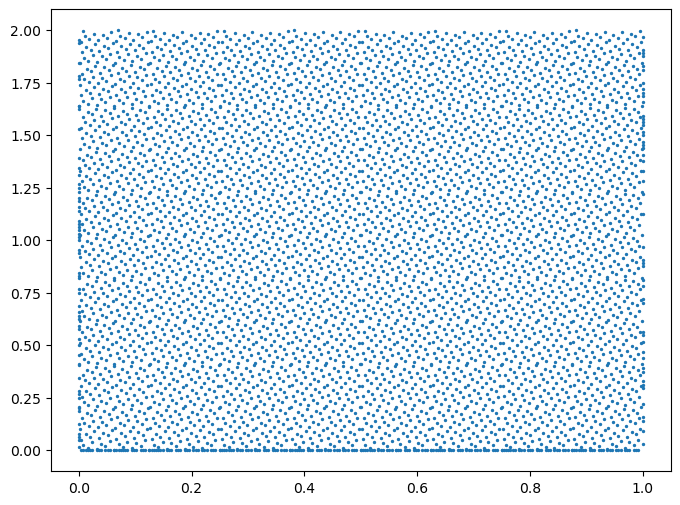

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(data.train_x_all[:, 0], data.train_x_all[:, 1], s=2)

In [11]:
model = dde.Model(data, network)

In [12]:
model.compile("adam", lr=1e-3)

Compiling model...
'compile' took 0.000203 s



In [13]:
losshistory, train_state = model.train(iterations = 20000)

Training model...

input_array [[0.       1.25    ]
 [0.       0.6875  ]
 [1.       0.03125 ]
 [1.       1.6875  ]
 [1.       1.5     ]
 [1.       0.46875 ]
 [1.       1.65625 ]
 [1.       0.90625 ]
 [0.       1.765625]
 [0.       1.3125  ]
 [1.       1.375   ]
 [0.       0.75    ]
 [1.       0.515625]
 [1.       0.3125  ]
 [0.       0.828125]
 [1.       1.453125]
 [0.       1.9375  ]
 [0.       0.9375  ]
 [0.       0.59375 ]
 [1.       0.140625]
 [0.       0.453125]
 [0.       1.078125]
 [0.       0.765625]
 [1.       1.578125]
 [0.       1.390625]
 [1.       1.90625 ]
 [0.       0.203125]
 [0.       0.046875]
 [0.       0.25    ]
 [0.       0.53125 ]
 [0.       1.953125]
 [0.       1.      ]
 [0.       0.578125]
 [0.       0.0625  ]
 [1.       1.4375  ]
 [0.       1.140625]
 [1.       1.125   ]
 [1.       0.328125]
 [1.       1.8125  ]
 [0.       0.125   ]
 [1.       1.75    ]
 [1.       0.546875]
 [1.       1.828125]
 [0.       1.03125 ]
 [0.       1.53125 ]
 [1.       1.5625  ]
 [0

In [14]:
dde.optimizers.config.set_LBFGS_options(maxiter = 5000)
model.compile("L-BFGS-B")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.003302 s

Training model...

Step      Train loss                        Test loss                         Test metric
20000     [2.49e-02, 6.52e-03, 2.09e-03]    [2.98e-03, 6.52e-03, 2.09e-03]    []  

Best model at step 19000:
  train loss: 1.34e-03
  test loss: 1.25e-03
  test metric: []

'train' took 0.027060 s



Saving loss history to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/My Codes/loss.dat ...
Saving training data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/My Codes/train.dat ...
Saving test data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/My Codes/test.dat ...


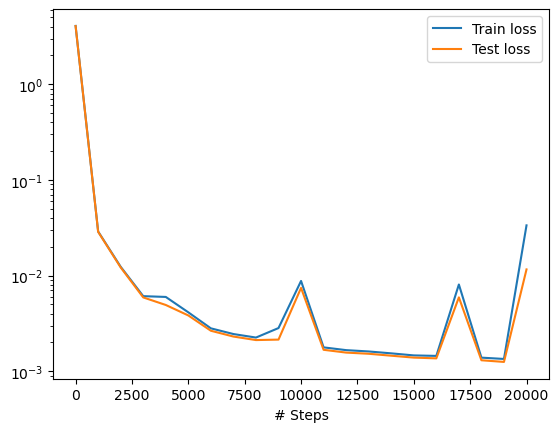

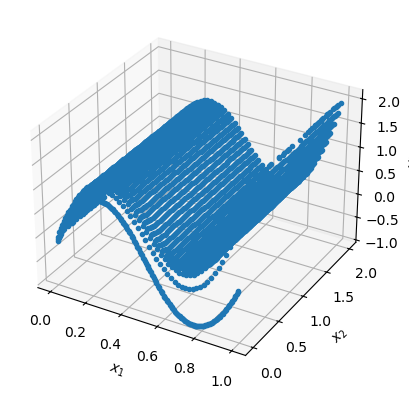

In [15]:
dde.saveplot(losshistory, train_state, issave = True, isplot = True)